Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Test samples: 7178

==================== Evaluation Metrics ====================
Overall Accuracy:      0.6651
Macro F1 Score:        0.6395   <-- Recommended metric
Balanced Accuracy:     0.6314

Classification Report:

              precision    recall  f1-score   support

       angry       0.58      0.57      0.58       958
     disgust       0.71      0.52      0.60       111
        fear       0.55      0.39      0.46      1024
       happy       0.88      0.86      0.87      1774
     neutral       0.60      0.68      0.64      1233
         sad       0.53      0.59      0.55      1247
    surprise       0.76      0.80      0.78       831

    accuracy                           0.67      7178
   macro avg       0.66      0.63      0.64      7178
weighted avg       0.67      0.67      0.66      7178



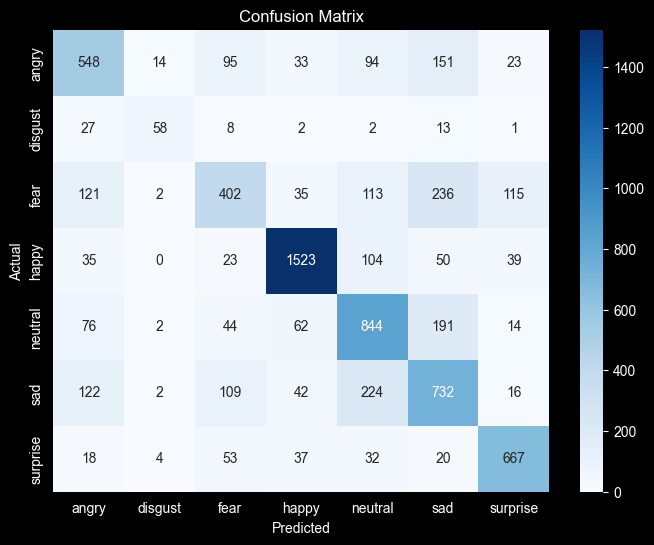


Per-Class Accuracy:
angry     : 0.5720
disgust   : 0.5225
fear      : 0.3926
happy     : 0.8585
neutral   : 0.6845
sad       : 0.5870
surprise  : 0.8026


In [1]:
# ======================================================
# Model Evaluation: Confusion Matrix + Detailed Metrics
# ======================================================

import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# ------------------------------------------------------
# Load trained model
# ------------------------------------------------------

model = models.mobilenet_v3_small(weights=None)

in_features = model.classifier[3].in_features

model.classifier[3] = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 7)
)

model.load_state_dict(torch.load(
    "checkpoints/mobilenet_v3_small_best_best.pth",
    map_location=device
))

model = model.to(device)
model.eval()


# ======================================================
# Create test dataset
# ======================================================

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_dataset = datasets.ImageFolder(
    "../data/raw/test",
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

class_names = test_dataset.classes

print("Classes:", class_names)
print("Test samples:", len(test_dataset))


# ======================================================
# Run inference
# ======================================================

from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, balanced_accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# ======================================================
# Overall Metrics
# ======================================================

overall_accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")
balanced_acc = balanced_accuracy_score(all_labels, all_preds)

print("\n==================== Evaluation Metrics ====================")
print(f"Overall Accuracy:      {overall_accuracy:.4f}")
print(f"Macro F1 Score:        {macro_f1:.4f}   <-- Recommended metric")
print(f"Balanced Accuracy:     {balanced_acc:.4f}")
print("=============================================================\n")


# ======================================================
# Classification Report
# ======================================================

print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


# ======================================================
# Confusion Matrix
# ======================================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# ======================================================
# Per-Class Accuracy
# ======================================================

print("\nPer-Class Accuracy:")

class_accuracy = cm.diagonal() / cm.sum(axis=1)

for i, cls in enumerate(class_names):
    print(f"{cls:10s}: {class_accuracy[i]:.4f}")

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Test samples: 7178

==================== Evaluation Metrics ====================
Overall Accuracy:      0.6955
Macro F1 Score:        0.6729   <-- Recommended metric
Balanced Accuracy:     0.6668

Classification Report:

              precision    recall  f1-score   support

       angry       0.62      0.61      0.61       958
     disgust       0.68      0.59      0.63       111
        fear       0.58      0.50      0.54      1024
       happy       0.87      0.89      0.88      1774
     neutral       0.63      0.69      0.66      1233
         sad       0.58      0.59      0.59      1247
    surprise       0.81      0.81      0.81       831

    accuracy                           0.70      7178
   macro avg       0.68      0.67      0.67      7178
weighted avg       0.69      0.70      0.69      7178



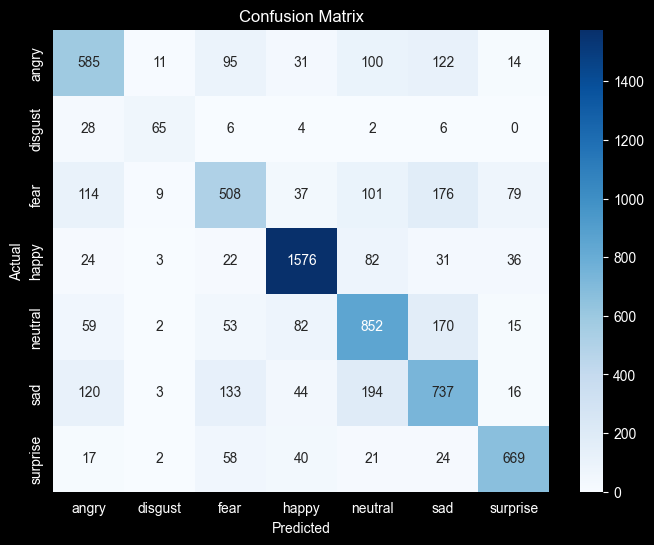


Per-Class Accuracy:
angry     : 0.6106
disgust   : 0.5856
fear      : 0.4961
happy     : 0.8884
neutral   : 0.6910
sad       : 0.5910
surprise  : 0.8051


In [2]:
# ======================================================
# Model Evaluation: Confusion Matrix + Detailed Metrics
# ======================================================

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# ------------------------------------------------------
# Load trained model
# ------------------------------------------------------

model = models.efficientnet_b0(weights=None)

in_features = model.classifier[1].in_features

model.classifier[1] = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 7)
)

model.load_state_dict(torch.load(
    "checkpoints/efficientNet_best_best.pth",
    map_location=device
))

model = model.to(device)
model.eval()


# ======================================================
# Create test dataset
# ======================================================

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_dataset = datasets.ImageFolder(
    "../data/raw/test",
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

class_names = test_dataset.classes

print("Classes:", class_names)
print("Test samples:", len(test_dataset))


# ======================================================
# Run inference
# ======================================================

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# ======================================================
# Overall Metrics
# ======================================================

overall_accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")
balanced_acc = balanced_accuracy_score(all_labels, all_preds)

print("\n==================== Evaluation Metrics ====================")
print(f"Overall Accuracy:      {overall_accuracy:.4f}")
print(f"Macro F1 Score:        {macro_f1:.4f}   <-- Recommended metric")
print(f"Balanced Accuracy:     {balanced_acc:.4f}")
print("=============================================================\n")


# ======================================================
# Classification Report
# ======================================================

print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


# ======================================================
# Confusion Matrix
# ======================================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# ======================================================
# Per-Class Accuracy
# ======================================================

print("\nPer-Class Accuracy:")

class_accuracy = cm.diagonal() / cm.sum(axis=1)

for i, cls in enumerate(class_names):
    print(f"{cls:10s}: {class_accuracy[i]:.4f}")

/Users/bsama/Desktop/Github emotion recognition/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Test samples: 7178

==================== Evaluation Metrics ====================
Overall Accuracy:      0.6672
Macro F1 Score:        0.6465   <-- Recommended metric
Balanced Accuracy:     0.6427

Classification Report:

              precision    recall  f1-score   support

       angry       0.60      0.56      0.58       958
     disgust       0.65      0.59      0.62       111
        fear       0.51      0.49      0.50      1024
       happy       0.87      0.86      0.87      1774
     neutral       0.60      0.67      0.63      1233
         sad       0.55      0.54      0.54      1247
    surprise       0.78      0.79      0.79       831

    accuracy                           0.67      7178
   macro avg       0.65      0.64      0.65      7178
weighted avg       0.67      0.67      0.67      7178



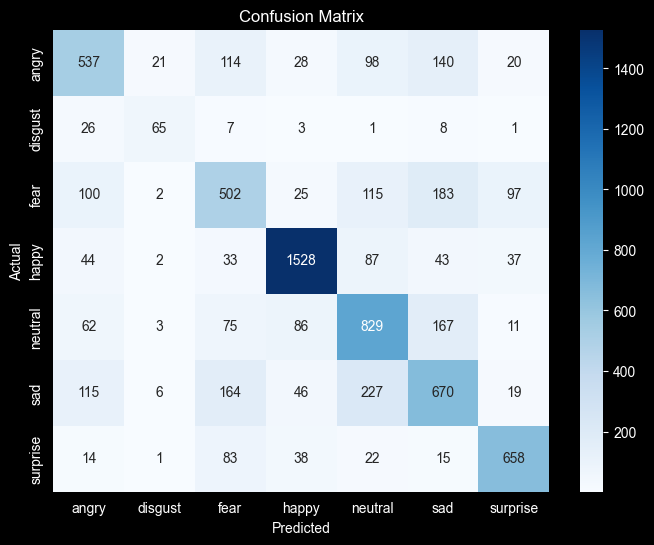


Per-Class Accuracy:
angry     : 0.5605
disgust   : 0.5856
fear      : 0.4902
happy     : 0.8613
neutral   : 0.6723
sad       : 0.5373
surprise  : 0.7918


In [3]:
# ======================================================
# Model Evaluation: Confusion Matrix + Detailed Metrics
# ======================================================

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# ------------------------------------------------------
# Load trained model
# ------------------------------------------------------

import timm

model = timm.create_model(
    "vit_small_patch16_224",
    pretrained=False,
    num_classes=7
)

model.load_state_dict(torch.load(
    "checkpoints/vit_small_best_best.pth",
    map_location=device
))

model = model.to(device)
model.eval()


# ======================================================
# Create test dataset
# ======================================================

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_dataset = datasets.ImageFolder(
    "../data/raw/test",
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

class_names = test_dataset.classes

print("Classes:", class_names)
print("Test samples:", len(test_dataset))


# ======================================================
# Run inference
# ======================================================

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# ======================================================
# Overall Metrics
# ======================================================

overall_accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")
balanced_acc = balanced_accuracy_score(all_labels, all_preds)

print("\n==================== Evaluation Metrics ====================")
print(f"Overall Accuracy:      {overall_accuracy:.4f}")
print(f"Macro F1 Score:        {macro_f1:.4f}   <-- Recommended metric")
print(f"Balanced Accuracy:     {balanced_acc:.4f}")
print("=============================================================\n")


# ======================================================
# Classification Report
# ======================================================

print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


# ======================================================
# Confusion Matrix
# ======================================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# ======================================================
# Per-Class Accuracy
# ======================================================

print("\nPer-Class Accuracy:")

class_accuracy = cm.diagonal() / cm.sum(axis=1)

for i, cls in enumerate(class_names):
    print(f"{cls:10s}: {class_accuracy[i]:.4f}")